# Module 6. Classification part 2
# Assessing performance
## Lecture objectives

1. Understand different ways to assess the predictive accuracy of a model

In the last lecture, we learned how to estimate a random forests model. But we skimmed over how to assess its predictive performance. 

First, let's recreate the same model we estimated before. Because we are using the `random_state` parameter, we should get exactly the same results as before.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# create the dataframe, including dummies
joinedDf = pd.read_pickle('../scratch/joined_permits.pandas')
dummies1 = pd.get_dummies(joinedDf.UseType, prefix='usetype_')  # creates a dataframe of dummies
dummies2 = pd.get_dummies(joinedDf.UseDescription, prefix='usedesc_')
joinedDf = joinedDf.join(dummies1).join(dummies2) 
xvars = (dummies1.columns.tolist() + dummies2.columns.tolist() + 
            ['YearBuilt1', 'Units1', 'Bedrooms1', 'Bathrooms1', 'SQFTmain1', 'Roll_LandValue', 
             'Roll_ImpValue', 'Roll_LandBaseYear', 'Roll_ImpBaseYear', 'CENTER_LAT', 'CENTER_LON' ])
yvar = 'hasADU'
df_to_fit = joinedDf[xvars+[yvar]].dropna()

# test-train split
X_train, X_test, y_train, y_test = train_test_split(
    df_to_fit[xvars], df_to_fit[yvar], test_size = 0.25, random_state = 1)

# estimate and fit the model
rf = RandomForestClassifier(n_estimators = 100, random_state = 1, n_jobs=-1) # n_jobs uses all your computer's cores
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

Let's also re-estimate the more simplified version of the model. That's because the real value of these performance assessments is to compare models - which predicts best?

In [2]:
xvars2 = ['SQFTmain1', 'Roll_LandValue', 'Roll_ImpValue']

# create a dataframe with no NaNs
df_to_fit2 = joinedDf[xvars2+[yvar]].dropna()

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    df_to_fit2[xvars2], df_to_fit2[yvar], test_size = 0.25, random_state = 1)

rf2 = RandomForestClassifier(n_estimators = 50, random_state = 1)
rf2.fit(X_train2, y_train2)
y_pred2 = rf2.predict(X_test2)

Last time we predicted that 0.1% of the parcels would have an ADU (0.06% in the stripped down, simplified model). Let's confirm we get the same overall prediction.

In [3]:
print('Predicted fraction True: {:.4f}. Actual fraction True: {:.4f}'.format(
    y_pred.mean(), y_test.mean()))

print('\nSimplified model:\nPredicted fraction True: {:.4f}. Actual fraction True: {:.4f}'.format(
    y_pred2.mean(), y_test2.mean()))
#2つ目の予測モデルではxvarsの数が少なかったので、予測精度も低い

Predicted fraction True: 0.0014. Actual fraction True: 0.0319

Simplified model:
Predicted fraction True: 0.0006. Actual fraction True: 0.0319


Let's look more formally at the predictive accuracy.

`scikit-learn` has several useful functions here:
* The [*confusion matrix*](https://en.wikipedia.org/wiki/Confusion_matrix) gives the number of observations that fall into each predicted and actual category (e.g is True and predicted to be True - a "true positive")
  Adamは、予測の正確さを評価するのにこれが一番使いやすいと感じている。真陽性・偽陽性などを明らかにすることができる。
* The [*accuracy score*](https://scikit-learn.org/stable/modules/model_evaluation.html#accuracy-score) gives the fraction of accurate predictions. A high score is no guarantee of a good model. Suppose you want to predict whether a person will be struck by lightening tomorrow. Then just predict "No" for everyone. Accurate, but not useful! **accuracy scoreは、被雷のようにそもそも発生確率が低い事象に対して使うと、それだけで点数が上がってしまう。つまり、本質を評価できていないので、使う場面（その事象の発生頻度）に注意が必要**
* The [*classification report*](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-report) reports key metrics for each category (in this case, `True` and `False`. *Precision* gives the fraction of true positives compared to the number of predicted positives (TP / (TP + FP) - basically, how many of our positive predictions are correct. *Recall* gives the fraction of true positives compared to the number of actual positives (TP / (TP + FN) - basically, what proportion of the positives did we correctly predict.
  classicifacion reportはprecisionとrecallの2種類がある。precisionは、真陽性/陽性すべて（真陽性+偽陽性）、recallは、真陽性/実際の数（真陽性+偽陰性）

In [4]:
#予測モデルの正確さを評価するためにscikit-learnが搭載しているfunctionとしては上の3つがある
#まずは一番直感的なconfusion matrixから説明する
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

print(confusion_matrix(y_test, y_pred))
confusion_matrix?

#下の結果において、左上はReal-world TrueかつPrediction Trueのパターン。ADUが無いとモデルでは予測されて、実際にADUが無いパターン
#左下は、Real-world TrueかつPrediction Falseのパターン。ADUが無いとモデルでは予測されていたが、実際にはADUがあるパターン


[[188094     71]
 [  6014    193]]


Signature:
confusion_matrix(
    y_true,
    y_pred,
    *,
    labels=None,
    sample_weight=None,
    normalize=None,
)
Docstring:
Compute confusion matrix to evaluate the accuracy of a classification.

By definition a confusion matrix :math:`C` is such that :math:`C_{i, j}`
is equal to the number of observations known to be in group :math:`i` and
predicted to be in group :math:`j`.

Thus in binary classification, the count of true negatives is
:math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
:math:`C_{1,1}` and false positives is :math:`C_{0,1}`.

Read more in the :ref:`User Guide <confusion_matrix>`.

Parameters
----------
y_true : array-like of shape (n_samples,)
    Ground truth (correct) target values.

y_pred : array-like of shape (n_samples,)
    Estimated targets as returned by a classifier.

labels : array-like of shape (n_classes), default=None
    List of labels to index the matrix. This may be used to reorder
    or select a subset of labels.
    If

In [5]:
#scikit-learnが搭載している評価機能2つ目のaccuracy_score
#正確度97%というのはかなり高い
#でもこれはADUがある、という事象の確率がそもそも低いことに起因している
#なので、上で被雷する確率の話で出ていたように、確率が低い事象だったら、
#とりあえず起こらない、に分類しておけば正確度は上がってしまう
print('Accuracy score: {:.4f}'.format(accuracy_score(y_test, y_pred)))

Accuracy score: 0.9687


In [6]:
#scikit-learnが搭載している評価機能の3つ目がclassification_report
#precisionのFalseというのは、Falseと予想した時に実際にFalseの場合の確率（0.97）
#precisionのTrueというのは、Trueと予測した時に実際にTrueの場合の確率（0.73）
#これらの予測2つに関しては比較的高い精度
#しかし、我々はrecallに関しては悪い。
#例えば、実際にTrueの場合のうち、予測がTrueの割合は0.03

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.97      1.00      0.98    188165
        True       0.73      0.03      0.06      6207

    accuracy                           0.97    194372
   macro avg       0.85      0.52      0.52    194372
weighted avg       0.96      0.97      0.95    194372



We can also plot the confusion matrix. Note the colorbar shows the number of observations.

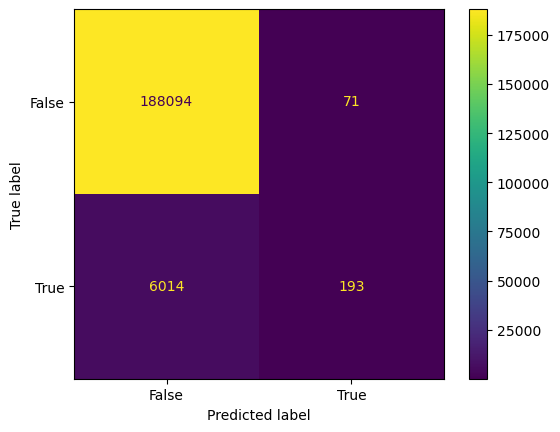

In [7]:
#Adamが好きな表示の仕方の1つ（confusion matrix）
#これから見て分かるように、実際がFalseの場合の精度は高い
#つまり、188,094+71件が実際にFalseで、そのうち188,094件を正確にFalseと予想している
#一方で実際にTrueだった場合の精度は低い
#つまり、6014+193件が実際にTrueだが、そのうちTrueと予測できたのは右下の193件
#一方で、false positive（右上）が少ない、というのは偽陽性が少ない、という事であり、これはよい点
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

How does this compare to our simplified model?

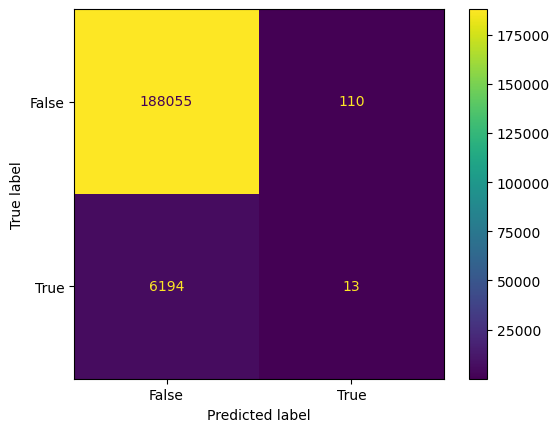

In [7]:
#これは上で作った単純化モデルの質評価
#これを見ると、上のモデルの方が、もちろん質は低いがそれでも単純化モデルよりは正確である事が分かる
ConfusionMatrixDisplay.from_predictions(y_test2, y_pred2)

So our model complex model does a bit better. In particular, we do a much better job in getting the true positives. 

It's still not great. But this is not surprising: ADU construction will depend on many factors that are outside our dataset: lot shape, the ability of the owners to afford an ADU, and their personal circumstances (e.g. having an elderly family member). Bringing in census data and other predictors might help.

But even if the predictions are not always accurate, the predicted *probabilities* can be informative. We could even map them to indicate where ADUs are likely to be built. 

We can access the probabilities from the `rf` object. Note it gives us a matrix: the first column is the probability of `False`, and the second is the probability of `True`.

In [8]:
#ここまででわかったように、モデルの評価は複雑
#rfを使うと、各サンプルがpositiveになる確率を出すことができる
#下のarrayにおいて、左側の列は、実際にFalseの確率。右側は実際にTrueの確率
rf.predict_proba(X_test)

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [0.98, 0.02],
       ...,
       [0.99, 0.01],
       [0.97, 0.03],
       [0.98, 0.02]])

Also note that we want to have the predicted probabilities of *all* the parcels - the test and the training datasets.

So we can concatenate the two dataframes.

In [10]:
rf.predict_proba(pd.concat([X_test,X_train]))

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [0.98, 0.02],
       ...,
       [0.27, 0.73],
       [0.92, 0.08],
       [0.99, 0.01]])

It's easy to turn an array like this into a pandas DataFrame.

In [11]:
# create a dataframe
predictions = pd.DataFrame(rf.predict_proba(pd.concat([X_test,X_train])), 
                           columns = ['pred_noADU', 'pred_ADU'])
predictions.head()

,pred_noADU,pred_ADU
0,1.00,0.00
1,1.00,0.00
2,0.98,0.02
3,1.00,0.00
4,0.93,0.07


Let's join our original test data back to these predictions. 

One wrinkle: we just have an integer index on `predictions`. Does this match `X_test`? 

In [12]:
X_test.head()

,usetype__Commercial,usetype__Government,usetype__Industrial,usetype__Institutional,usetype__Irrigated Farm,usetype__Miscellaneous,usetype__Recreational,usetype__Residential,usedesc__Animal Kennels,usedesc__Athletic & Amusement Facilities,...,Units1,Bedrooms1,Bathrooms1,SQFTmain1,Roll_LandValue,Roll_ImpValue,Roll_LandBaseYear,Roll_ImpBaseYear,CENTER_LAT,CENTER_LON
APN,,,,,,,,,,,,,,,,,,,,,
2871-007-011,False,False,False,False,False,False,False,True,False,False,...,1.0,3.0,2.0,1418.0,120832.0,181262.0,1986,1986,34.282842,-118.543829
5128-004-041,False,False,True,False,False,False,False,False,False,False,...,0.0,0.0,0.0,45647.0,3764876.0,3909893.0,2016,2016,34.021904,-118.270001
5577-010-002,False,False,False,False,False,False,False,True,False,False,...,1.0,3.0,2.0,1423.0,425839.0,204140.0,2007,2007,34.118243,-118.336285
5105-020-032,False,False,True,False,False,False,False,False,False,False,...,1.0,0.0,0.0,3480.0,115890.0,360997.0,2006,2012,33.989503,-118.244341
4105-002-008,False,False,False,False,False,False,False,True,False,False,...,1.0,3.0,3.0,2053.0,431574.0,392997.0,1992,1992,33.971712,-118.384078


No, that has the original `APN` index. Fortunately, `reset_index()` will change the index to a sequential integer index.

In [13]:
predictions= predictions.join(pd.concat([X_test,X_train]).reset_index())
predictions.head()

,pred_noADU,pred_ADU,APN,usetype__Commercial,usetype__Government,usetype__Industrial,usetype__Institutional,usetype__Irrigated Farm,usetype__Miscellaneous,usetype__Recreational,...,Units1,Bedrooms1,Bathrooms1,SQFTmain1,Roll_LandValue,Roll_ImpValue,Roll_LandBaseYear,Roll_ImpBaseYear,CENTER_LAT,CENTER_LON
0,1.00,0.00,2871-007-011,False,False,False,False,False,False,False,...,1.0,3.0,2.0,1418.0,120832.0,181262.0,1986,1986,34.282842,-118.543829
1,1.00,0.00,5128-004-041,False,False,True,False,False,False,False,...,0.0,0.0,0.0,45647.0,3764876.0,3909893.0,2016,2016,34.021904,-118.270001
2,0.98,0.02,5577-010-002,False,False,False,False,False,False,False,...,1.0,3.0,2.0,1423.0,425839.0,204140.0,2007,2007,34.118243,-118.336285
3,1.00,0.00,5105-020-032,False,False,True,False,False,False,False,...,1.0,0.0,0.0,3480.0,115890.0,360997.0,2006,2012,33.989503,-118.244341
4,0.93,0.07,4105-002-008,False,False,False,False,False,False,False,...,1.0,3.0,3.0,2053.0,431574.0,392997.0,1992,1992,33.971712,-118.384078


Now, let's map these predictions.

<div class="alert alert-block alert-info">
    <strong>Exercise:</strong> Convert your dataframe, <strong>predictions</strong> to a GeoDataFrame that includes a geometry column.
</div>

In [14]:
import geopandas as gpd
predictions = gpd.GeoDataFrame(predictions, 
                    geometry = gpd.points_from_xy(
                        predictions.CENTER_LON, 
                        predictions.CENTER_LAT, crs='EPSG:4326'))

[]

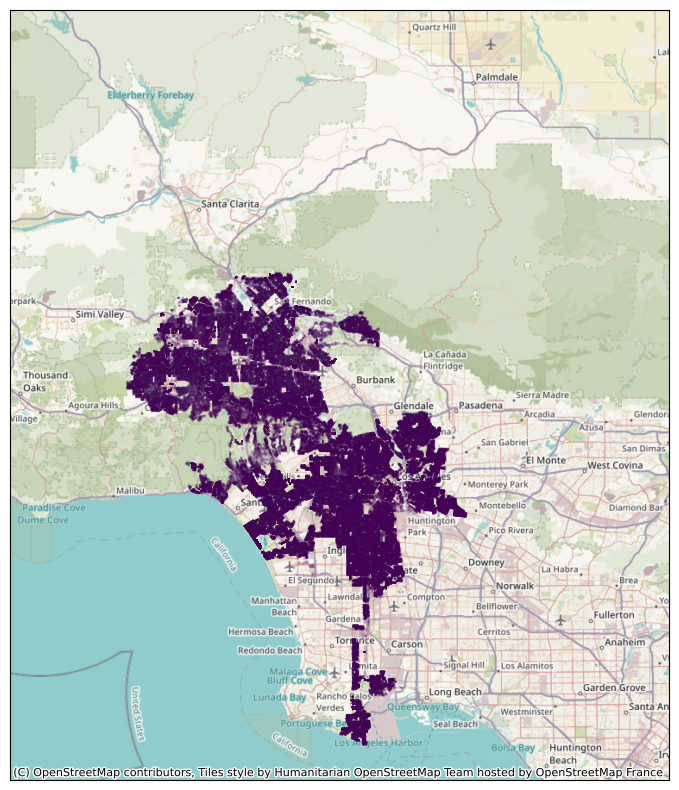

In [15]:
import contextily as ctx
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,10))
predictions.to_crs('EPSG:3857').plot('pred_ADU', markersize=0.001, ax=ax)
ctx.add_basemap(ax=ax)
ax.set_xticks([])
ax.set_yticks([])

Actually, this map says more about where parcels overlap rather than the presence of an ADU. There are a couple of strategies that we might use to avoid this:
* Don't plot parcels with less than a certain probability of having an ADU
* Use a different colormap (the `cmap` argument)
* Use a smaller marker size (to avoid some overlap) (the `markersize` argument)
* Scale the colormap so that it tops out at a lower value (the `vmax` argument)

Let's try the first and fourth approaches.

[]

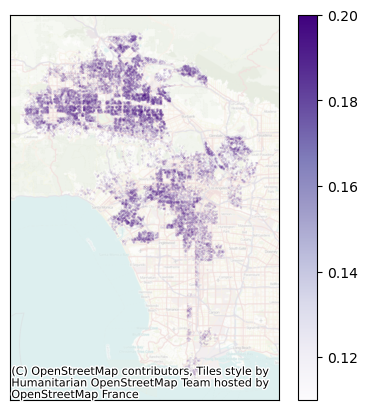

In [16]:
fig, ax = plt.subplots(figsize=(5,5))
#pred_ADUの値が0.1より大きいものだけをピックアップ（予想確率が高いものだけを選択）
#vmax=0.2、ということは、0.2以上は0.3だろうと0.4だろうとすべて同じ扱いになる、ということ
predictions[predictions.pred_ADU>0.1].to_crs('EPSG:3857').plot('pred_ADU', cmap='Purples', markersize=0.001, 
                                     vmax=0.2, ax=ax, legend=True)
ctx.add_basemap(ax=ax, alpha = 0.3)
ax.set_xticks([])
ax.set_yticks([])

<div class="alert alert-block alert-info">
    <strong>Exercise:</strong> Experiment with different values for <strong>vmax</strong>. What does this parameter do?
</div>

<div class="alert alert-block alert-info">
    <strong>Exercise:</strong> What other colormaps can you use? Explore the matplotlib documentation.
</div>

Hmm. Maybe changing the marker size is a better way to go than a color.

We can do this by scaling the column that we plot.

[]

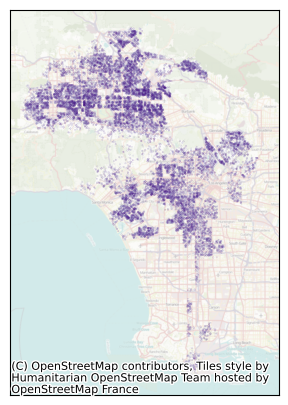

In [17]:
import contextily as ctx
import matplotlib.pyplot as plt

predictions['pred_ADU_scaled'] = predictions.pred_ADU*0.01
fig, ax = plt.subplots(figsize=(5,5))
predictions[predictions.pred_ADU>0.1].to_crs('EPSG:3857').plot(cmap='Purples', 
                                     markersize='pred_ADU_scaled', 
                                     ax=ax, legend=True)
ctx.add_basemap(ax=ax, alpha=0.4)
ax.set_xticks([])
ax.set_yticks([])

It's still not clear how to distinguish areas with lots of parcels from areas with few parcels but a high propensity to have an ADU. Any ideas? 

We'll leave the mapping here, but my inclination would be to aggregate to a grid or to census block groups, in order to make the propensity to have an ADU a bit clearer.

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
  <li>Confusion matrices are an excellent way to assess predictive performance, particularly for binary outcomes.</li>
  <li>Mapping and other descriptive plots are also good ways to explore the outputs.</li>
</ul>
</div>